In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from quantlib.research.data import (
    fetch_indicator_dataframe,
)
from quantlib.building_blocks.strategy import indicators
from quantlib.building_blocks.trading_environment import (
    instruments,
)
from quantlib.building_blocks import bars, intervals
from quantsdk.tools.rounding import round_down
from typing import Literal


In [2]:
target_instrument = instruments.BinanceFuturesUSDM.DOGEUSDT
candle_size = intervals.CandlestickInterval(hours=4)
price_open = indicators.Open(
    instrument=target_instrument,
    bar_type=bars.CandlestickTimeBar(
        interval=candle_size,
    ),
)
price_close = indicators.Close(
    instrument=target_instrument,
    bar_type=bars.CandlestickTimeBar(
        interval=candle_size,
    ),
)

indicator_df = fetch_indicator_dataframe(
    indicators=[
        indicators.OpenTimestamp(
            instrument=target_instrument,
            bar_type=bars.CandlestickTimeBar(
                interval=candle_size,
            ),
        ).alias("open_timestamp"),
        price_open.alias("open"),
        price_close.alias("close"),
    ],
    start_date="2023-01-01",
    end_date="2024-01-01",
)

INFO:quantops.controls.cached_secret:Fetching supported backtesting dates...
INFO:quantde.market_data.history.local_market_data:[quant-de] Processing market data for ['DOGEUSDT']...


[quant-de] Retrieving market data from local db...


In [3]:
indicator_df

,data_available_at_timestamp_integer_ms,data_available_at_datetime,open_timestamp,open,close
0,1672545600000,2023-01-01 04:00:00,2023-01-01 00:00:00,0.07022,0.06981
1,1672560000000,2023-01-01 08:00:00,2023-01-01 04:00:00,0.06982,0.06943
2,1672574400000,2023-01-01 12:00:00,2023-01-01 08:00:00,0.06942,0.06962
3,1672588800000,2023-01-01 16:00:00,2023-01-01 12:00:00,0.06963,0.06972
4,1672603200000,2023-01-01 20:00:00,2023-01-01 16:00:00,0.06972,0.07030
...,...,...,...,...,...
2185,1704009600000,2023-12-31 08:00:00,2023-12-31 04:00:00,0.08974,0.09057
2186,1704024000000,2023-12-31 12:00:00,2023-12-31 08:00:00,0.09057,0.09050
2187,1704038400000,2023-12-31 16:00:00,2023-12-31 12:00:00,0.09051,0.09019
2188,1704052800000,2023-12-31 20:00:00,2023-12-31 16:00:00,0.09019,0.09038


In [4]:
# Let the strategy be buys at with (D % 5 = 0 @ 0h) days of max holding period of 12 candles of 4 hours
# Four scenarios: trading the entire balance available, trading a fixed amount of capital, trading a fixed lot size, and computing log returns
initial_capital = 10000
fixed_capital_hypothesis = initial_capital
fixed_lot_hypothesis = 100000
holding_period = 12
df = indicator_df[["open_timestamp", "open", "close"]].copy()
df["entry_signal_raw"] = (df["open_timestamp"].dt.day % 5 == 0) & (df["open_timestamp"].dt.hour == 0)

# backtesting solely via pandas operations:
df["close_log_return"] = np.log(df["close"]).diff()
df["positioned_et_end_of_bar"] = (df["entry_signal_raw"]).astype(int)
df.loc[[i for i in df[df["entry_signal_raw"]].index.values + holding_period if i <= df.index[-1]], "positioned_et_end_of_bar"] = -1 # exiting after holding_period bars
df["positioned_et_end_of_bar"] = df["positioned_et_end_of_bar"].cumsum()
df["pd_bt_log_return_daily"] = (df["positioned_et_end_of_bar"]* df["close_log_return"]).shift(1).fillna(0)
df["pd_bt_cumulative_log_return"] = (df["pd_bt_log_return_daily"]).cumsum()


# row by row backtesting:
df["return_trading_entire_balance"] = 0.0
df["return_trading_fixed_capital"] = 0.0
df["return_trading_fixed_lot"] = 0.0
df["return_log"] = 0
balance = initial_capital

i=0
# we will trade at the bar's open, so our prices are either the open prices or the close prices of the previous bar. Will assume close prices of previous bar.
print("entry_signal", "open_timestamp", "will_exit_at", "holding_period", "holding_period in bars", "balance", "volume_to_buy_with_fixed_capital", "entry_price", "exit_price", "actual_return_with_fixed_capital", "actual_return_with_balance", "actual_return_with_fixed_lot", "log_return")
while i < len(df) - holding_period:

    open_timestamp = df.iloc[i]["open_timestamp"] 

    if open_timestamp.day % 5 == 0 and open_timestamp.hour == 0: # trade rule
        entry_signal = df.iloc[i]["entry_signal_raw"]

        _exiting_index = i + holding_period # as soon as this bar opens, or, as soon as its previous bar closes
        entry_price = df.iloc[i-1]["close"] # close price of the previous bar. We act as soon as the bar closes, and, if we are fast enough, we define the next bar open.
        exit_price = df.iloc[_exiting_index-1]["close"] # analogous to entry 
        will_exit_at = df.iloc[_exiting_index]["open_timestamp"]
        price_change = exit_price - entry_price
        price_pct_change = (price_change) / entry_price
        log_return = np.log(exit_price) - np.log(entry_price)

        volume_to_buy_with_balance = balance / entry_price
        volume_to_buy_with_fixed_capital = fixed_capital_hypothesis / entry_price
        volume_to_buy_with_fixed_lot = fixed_lot_hypothesis

        volume_to_buy_with_balance = round_down(volume_to_buy_with_balance,5)
        volume_to_buy_with_fixed_capital = round_down(volume_to_buy_with_fixed_capital,5)
        volume_to_buy_with_fixed_lot = round_down(volume_to_buy_with_fixed_lot,5)

        actual_return_with_balance = volume_to_buy_with_balance * price_change
        actual_return_with_fixed_capital = volume_to_buy_with_fixed_capital * price_change
        actual_return_with_fixed_lot = volume_to_buy_with_fixed_lot * price_change

        df.loc[_exiting_index, "return_trading_entire_balance"] = actual_return_with_balance
        df.loc[_exiting_index, "return_trading_fixed_capital"] = actual_return_with_fixed_capital
        df.loc[_exiting_index, "return_trading_fixed_lot"] = actual_return_with_fixed_lot
        df.loc[_exiting_index, "return_log"] = log_return

        balance += actual_return_with_balance

        print(entry_signal, open_timestamp, will_exit_at, will_exit_at-open_timestamp, _exiting_index-i,balance, volume_to_buy_with_fixed_capital, entry_price, exit_price, actual_return_with_fixed_capital, actual_return_with_balance, actual_return_with_fixed_capital, log_return)

        i = _exiting_index  # skip to the exit point
    else:
        i+=1

entry_signal open_timestamp will_exit_at holding_period holding_period in bars balance volume_to_buy_with_fixed_capital entry_price exit_price actual_return_with_fixed_capital actual_return_with_balance actual_return_with_fixed_lot log_return
True 2023-01-05 00:00:00 2023-01-07 00:00:00 2 days 00:00:00 12 9904.214559389 136836.34373 0.07308 0.07238 -95.78544061100084 -95.78544061100084 -95.78544061100084 -0.00962471337420956
True 2023-01-10 00:00:00 2023-01-12 00:00:00 2 days 00:00:00 12 10228.8570667522 132170.23526 0.07566 0.07814 327.78218344479944 324.64250736319946 327.78218344479944 0.032252470422041046
True 2023-01-15 00:00:00 2023-01-17 00:00:00 2 days 00:00:00 12 9807.1451400562 114521.30096 0.08732 0.08372 -412.2766834559991 -421.71192669599907 -412.2766834559991 -0.042101634103944185
True 2023-01-20 00:00:00 2023-01-22 00:00:00 2 days 00:00:00 12 10182.1242189202 122549.0196 0.0816 0.08472 382.35294115199974 374.9790788639997 382.35294115199974 0.03752243932308996
True 2023-

In [5]:
df.head(30)

,open_timestamp,open,close,entry_signal_raw,close_log_return,positioned_et_end_of_bar,pd_bt_log_return_daily,pd_bt_cumulative_log_return,return_trading_entire_balance,return_trading_fixed_capital,return_trading_fixed_lot,return_log
0,2023-01-01 00:00:00,0.07022,0.06981,False,NaN,0,0.000000,0.000000,0.0,0.0,0.0,0.0
1,2023-01-01 04:00:00,0.06982,0.06943,False,-0.005458,0,0.000000,0.000000,0.0,0.0,0.0,0.0
2,2023-01-01 08:00:00,0.06942,0.06962,False,0.002733,0,-0.000000,0.000000,0.0,0.0,0.0,0.0
3,2023-01-01 12:00:00,0.06963,0.06972,False,0.001435,0,0.000000,0.000000,0.0,0.0,0.0,0.0
4,2023-01-01 16:00:00,0.06972,0.07030,False,0.008285,0,0.000000,0.000000,0.0,0.0,0.0,0.0
5,2023-01-01 20:00:00,0.07029,0.07020,False,-0.001423,0,0.000000,0.000000,0.0,0.0,0.0,0.0
6,2023-01-02 00:00:00,0.07020,0.06998,False,-0.003139,0,-0.000000,0.000000,0.0,0.0,0.0,0.0
7,2023-01-02 04:00:00,0.06999,0.07178,False,0.025396,0,-0.000000,0.000000,0.0,0.0,0.0,0.0
8,2023-01-02 08:00:00,0.07177,0.07179,False,0.000139,0,0.000000,0.000000,0.0,0.0,0.0,0.0
9,2023-01-02 12:00:00,0.07179,0.07236,False,0.007908,0,0.000000,0.000000,0.0,0.0,0.0,0.0


<Axes: xlabel='open_timestamp'>

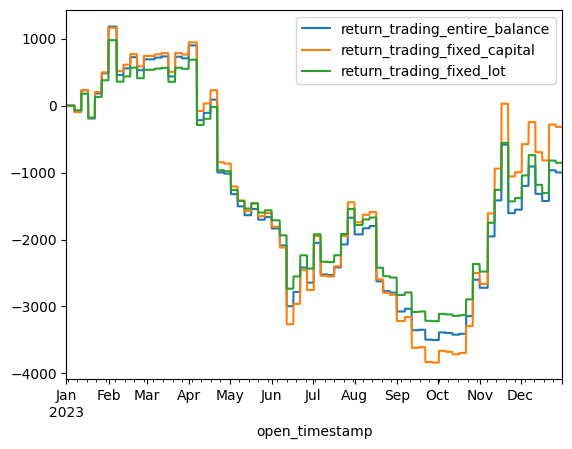

In [6]:
df.set_index("open_timestamp")[["return_trading_entire_balance", "return_trading_fixed_capital", "return_trading_fixed_lot"]].cumsum().plot()

<Axes: >

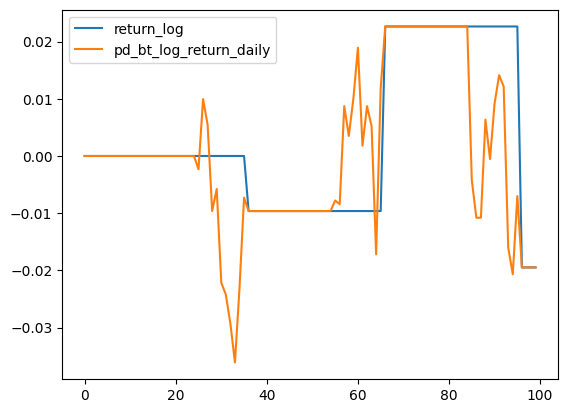

In [7]:
# Because pd_bt_log_return_daily is calculate for every bar, and not only trading bars, it serves as a proxy for marking to market.
df[["return_log", "pd_bt_log_return_daily"]].cumsum()[:100].plot()

In [8]:
# Placing each return on the same scale (a initial capital of 10000):
# Note that some of these scenarios are unfeasible in practice due to the losses change the available balance, which may prevent opening new positions with the same volume as initially intended.

dff = df.set_index("open_timestamp")[["return_trading_entire_balance", "return_trading_fixed_capital", "return_trading_fixed_lot"]].copy()
dff.iloc[0] = initial_capital
dff = dff.cumsum()
dff = dff/initial_capital - 1
dff["log_return"] = df["return_log"].cumsum().values
dff["pd_bt_log_return"] = df["pd_bt_log_return_daily"].cumsum().values

In [9]:
dff

,return_trading_entire_balance,return_trading_fixed_capital,return_trading_fixed_lot,log_return,pd_bt_log_return
open_timestamp,,,,,
2023-01-01 00:00:00,0.000000,0.000000,0.0000,0.000000,0.000000
2023-01-01 04:00:00,0.000000,0.000000,0.0000,0.000000,0.000000
2023-01-01 08:00:00,0.000000,0.000000,0.0000,0.000000,0.000000
2023-01-01 12:00:00,0.000000,0.000000,0.0000,0.000000,0.000000
2023-01-01 16:00:00,0.000000,0.000000,0.0000,0.000000,0.000000
...,...,...,...,...,...
2023-12-31 04:00:00,-0.099831,-0.031899,-0.0854,-0.105172,-0.119445
2023-12-31 08:00:00,-0.099831,-0.031899,-0.0854,-0.105172,-0.110238
2023-12-31 12:00:00,-0.099831,-0.031899,-0.0854,-0.105172,-0.111012


<Axes: xlabel='open_timestamp'>

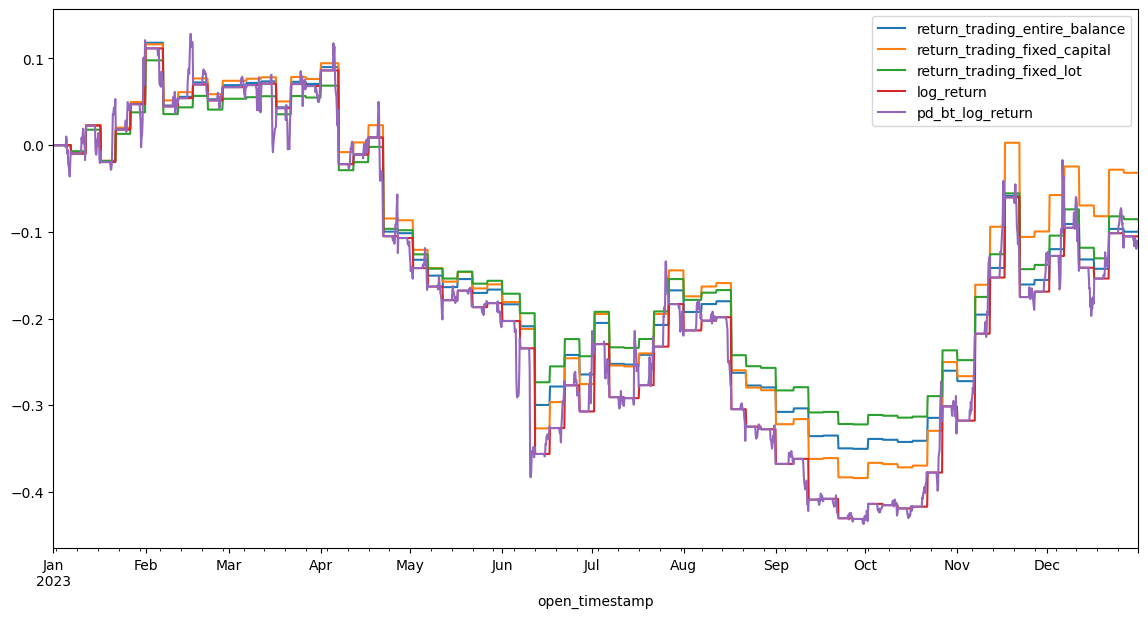

In [10]:
fig, ax = plt.subplots(figsize=(14, 7))
(dff[["return_trading_entire_balance", "return_trading_fixed_capital","return_trading_fixed_lot", "log_return", "pd_bt_log_return"]]).plot(ax=ax)

### Comparison with backtests from quantlib (see appendix A for reference code)

In [11]:
portfolio_history_comparison_scenarios_from_quantlib_backtests = pd.read_csv(
    "portfolio_history_comparison_scenarios.csv",
)
portfolio_history_comparison_scenarios_from_quantlib_backtests["date"] = pd.to_datetime(
    portfolio_history_comparison_scenarios_from_quantlib_backtests["date"]
)
portfolio_history_comparison_scenarios_from_quantlib_backtests

,date,symbol,mark_to_market_price,pnl_mm,volume_cum,mean_price,pnl_deals,pnl_mm_this_day,pnl_total,pnl_total_cum,number_of_orders,configuration,slippage,trading_fee,pnl_total_cum_deals,Slippage / Fee
0,2023-01-01,DOGE/USDT,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,fixed_margin,0.0000,0.0000,0.000000,0.00% - 0.00%
1,2023-01-02,DOGE/USDT,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,fixed_margin,0.0000,0.0000,0.000000,0.00% - 0.00%
2,2023-01-03,DOGE/USDT,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,fixed_margin,0.0000,0.0000,0.000000,0.00% - 0.00%
3,2023-01-04,DOGE/USDT,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,fixed_margin,0.0000,0.0000,0.000000,0.00% - 0.00%
4,2023-01-05,DOGE/USDT,0.071480,-207.783459,129864.662,0.073080,0.000000,-207.783459,-207.783459,-207.783459,1.0,fixed_margin,0.0000,0.0000,0.000000,0.00% - 0.00%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5835,2023-12-27,DOGE/USDT,0.093799,0.000000,0.000,0.000000,-36.851838,36.851838,0.000000,-1840.213216,1.0,full_balance,0.0002,0.0005,-1840.213216,0.02% - 0.05%
5836,2023-12-28,DOGE/USDT,0.091818,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,-1840.213216,0.0,full_balance,0.0002,0.0005,-1840.213216,0.02% - 0.05%
5837,2023-12-29,DOGE/USDT,0.091048,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,-1840.213216,0.0,full_balance,0.0002,0.0005,-1840.213216,0.02% - 0.05%
5838,2023-12-30,DOGE/USDT,0.090052,-93.335662,89638.436,0.091048,-4.080709,-93.335662,-97.416372,-1937.629587,1.0,full_balance,0.0002,0.0005,-1844.293925,0.02% - 0.05%


In [12]:
def plot_quantlib_vs_notebook(
    exposure_scenario: Literal["fixed_margin", "fixed_capital", "fixed_lots", "full_balance"],
    pnl_origin: Literal["deals", "mark_to_market_included"]=None
):
    fig, ax = plt.subplots(figsize=(14, 7))
    
    subset = portfolio_history_comparison_scenarios_from_quantlib_backtests[
    (portfolio_history_comparison_scenarios_from_quantlib_backtests["configuration"] == exposure_scenario)
    & (portfolio_history_comparison_scenarios_from_quantlib_backtests["Slippage / Fee"] == "0.00% - 0.00%")
    ].set_index("date")

    plt.plot(subset.index, subset["pnl_total_cum_deals"], label=f"quantlib - {exposure_scenario} - no costs - deals", color="black", linewidth=2)
    plt.plot(subset.index, subset["pnl_total_cum"], label=f"quantlib - {exposure_scenario} - no costs - MtM", color="black", linewidth=1, linestyle="--")

    df.set_index("open_timestamp")[["return_trading_entire_balance", "return_trading_fixed_capital", "return_trading_fixed_lot"]].cumsum().plot(ax=ax)

    ax.legend()
    plt.title(f"Cumulative Returns Comparison - quantlib '{exposure_scenario}' vs. Notebook backtests")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Returns [USDT]")
    

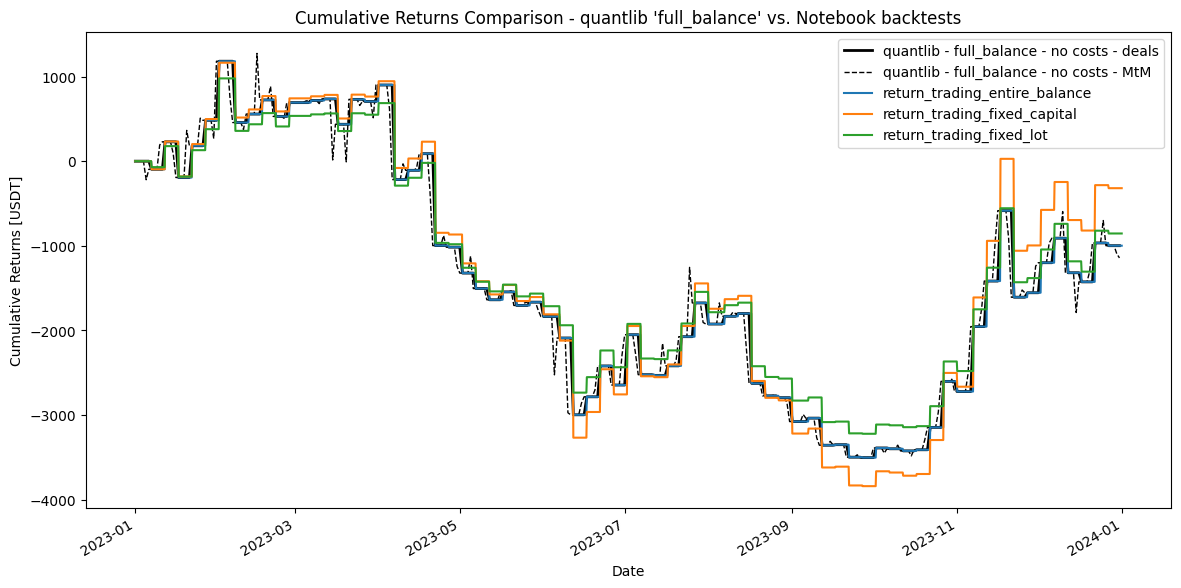

In [13]:
plot_quantlib_vs_notebook("full_balance")

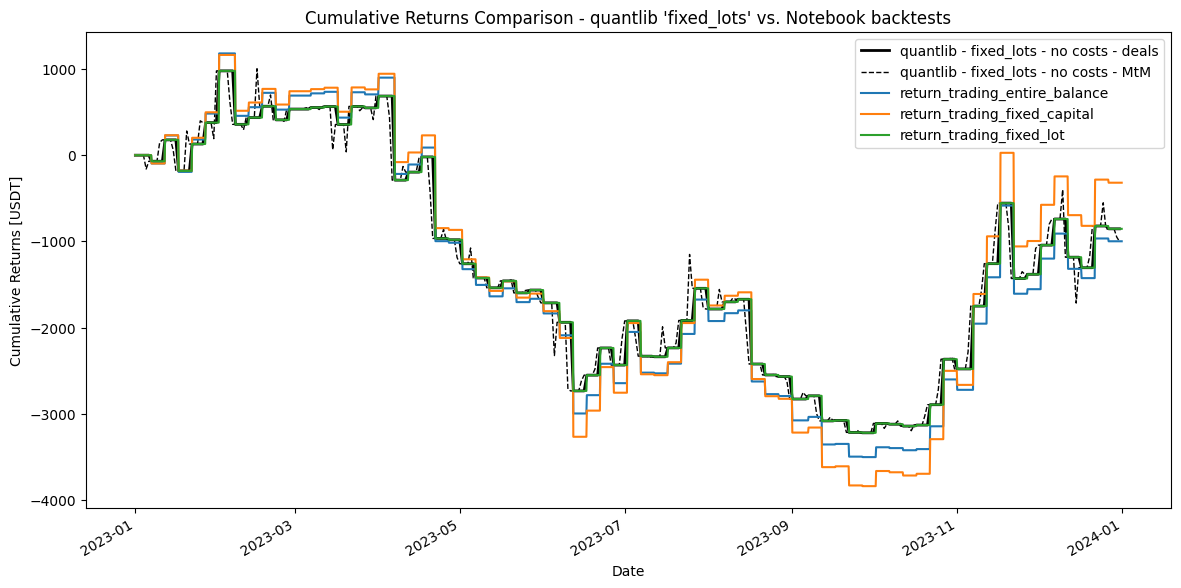

In [14]:
plot_quantlib_vs_notebook("fixed_lots")

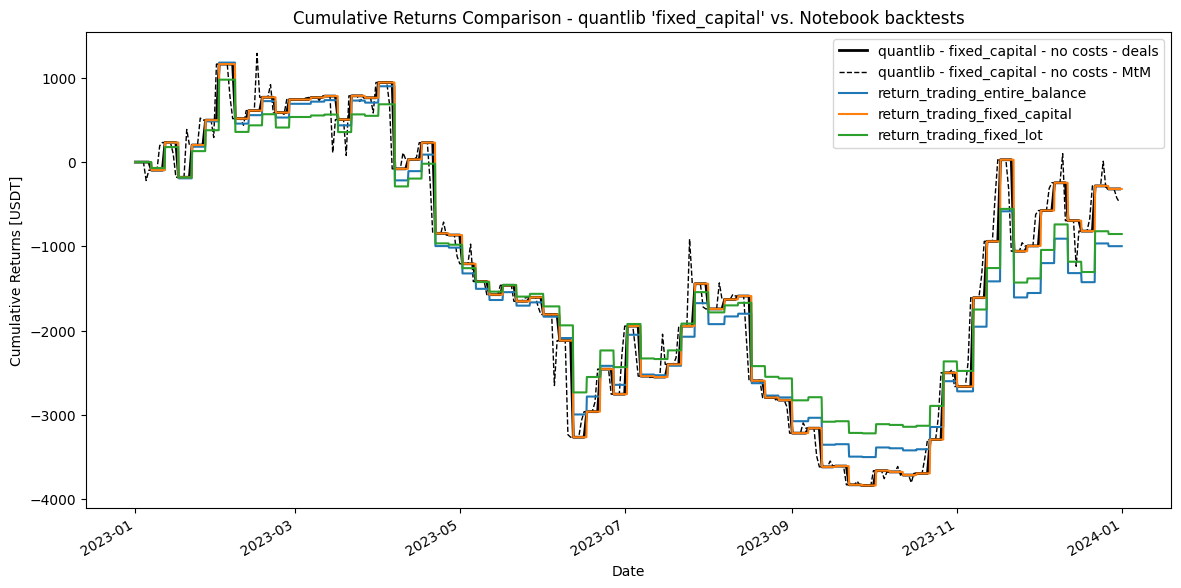

In [15]:
plot_quantlib_vs_notebook("fixed_capital")

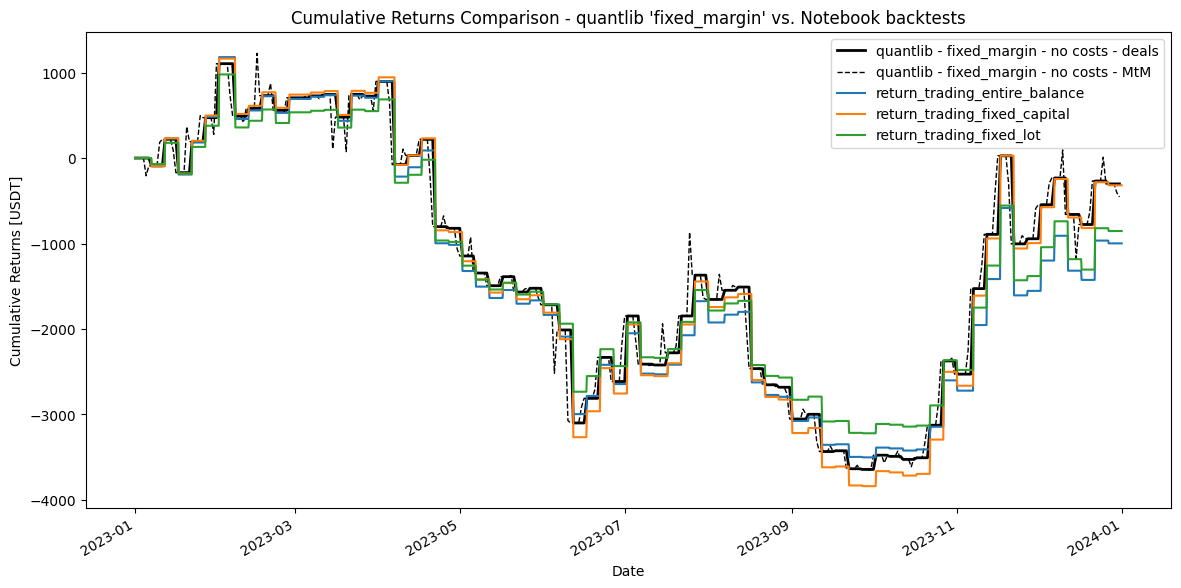

In [16]:
plot_quantlib_vs_notebook("fixed_margin")

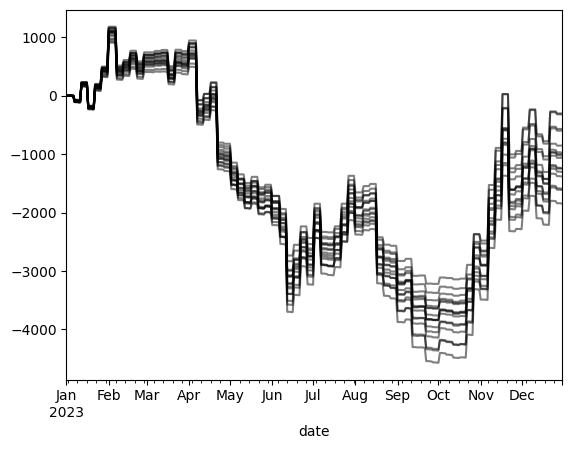

In [17]:
# Curves from quantlib - with costs
fig, ax = plt.subplots()
for configuration in portfolio_history_comparison_scenarios_from_quantlib_backtests[
    "configuration"
].unique():
    for slippage_fee in portfolio_history_comparison_scenarios_from_quantlib_backtests[
        "Slippage / Fee"
    ].unique():
        subset = portfolio_history_comparison_scenarios_from_quantlib_backtests[
            (portfolio_history_comparison_scenarios_from_quantlib_backtests["configuration"]
             == configuration)
            & (portfolio_history_comparison_scenarios_from_quantlib_backtests["Slippage / Fee"]
               == slippage_fee)
        ]
        subset.set_index("date")["pnl_total_cum_deals"].plot(ax=ax,color="black",alpha=0.5)

### Appendix A

In [ ]:
import logging
from typing import Literal
from quantlib.backtester import backtest, load_backtest_results
from quantlib.backtester.custom_strategies import (
    UserDefinedStrategyHandler,
    PreparedOrder,
    OrderSide,
)
from quantlib.building_blocks.strategy import (
    indicators,
    take_profit,
    stop_loss,
    trading_signals,
    options,
)
from quantlib.building_blocks import bars, intervals, data_catalogue
from quantlib.building_blocks.trading_environment import instruments
from quantlib.backtester.standards import BacktestStandards
from quantsdk.symbols import TradingSymbol
from quantlib.experimental import PortfolioHolderMetadata
import pandas as pd
import numpy as np
from quantlib.building_blocks.trading_environment import (
    TradingEnvironment,
    markets,
    exchange,
)
from pathlib import Path

logging.basicConfig()
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)


pd.options.display.max_columns = None

Configuration = Literal["fixed_margin", "fixed_capital", "fixed_lots", "full_balance"]

portfolio_histories = []
for CONFIGURATION in ["fixed_margin", "fixed_capital", "fixed_lots", "full_balance"]:
    for COST_STRUCTURE in [
        dict(
            slippage=0.00 / 100,
            trading_fee=0.00 / 100,
        ),
        dict(
            slippage=0.02 / 100,
            trading_fee=0.00 / 100,
        ),
        dict(
            slippage=0.00 / 100,
            trading_fee=0.05 / 100,
        ),
        dict(
            slippage=0.02 / 100,
            trading_fee=0.05 / 100,
        ),
    ]:

        class MyStrategy(UserDefinedStrategyHandler):

            def handle_hook(self) -> list[PreparedOrder]:

                initial_capital = 10000
                balance = (
                    initial_capital
                    + self.get_deals_history_dataframe()["profit_net"].sum()
                )
                now = self.get_current_timestamp()
                open_positions = self.get_open_positions()

                _prepared_orders = []

                if now.day % 5 == 0 and now.hour == 0:
                    for symbol in self.get_trading_symbols(return_type="Instrument"):

                        symbol_price = self.query_indicators_as_dataframe(
                            indicators=[
                                indicators.Close(
                                    instrument=symbol,
                                    bar_type=bars.CandlestickTimeBar(
                                        interval=intervals.CandlestickInterval(hours=4)
                                    ),
                                ).alias("close"),
                            ]
                        )
                        symbol_price = symbol_price["close"].iloc[-1]
                        volume_fixed_capital = 10000 / symbol_price
                        volume_balance = balance / symbol_price
                        volume_fixed_lots = 100000

                        if CONFIGURATION == "fixed_margin":
                            prepare_orders_argument = dict(
                                symbol=symbol,
                                leverage=1,
                                margin_exposure=10000,
                                target_net_order=True,
                                target_net_direction="long",
                            )
                        elif CONFIGURATION == "fixed_capital":
                            prepare_orders_argument = dict(
                                symbol=symbol,
                                volume=volume_fixed_capital,
                                order_side=self.order_sides.BUY,
                            )
                        elif CONFIGURATION == "fixed_lots":
                            prepare_orders_argument = dict(
                                symbol=symbol,
                                volume=volume_fixed_lots,
                                order_side=self.order_sides.BUY,
                            )
                        elif CONFIGURATION == "full_balance":
                            prepare_orders_argument = dict(
                                symbol=symbol,
                                volume=volume_balance,
                                order_side=self.order_sides.BUY,
                            )

                        _prepared_orders.append(
                            self.prepare_order(**prepare_orders_argument)
                        )

                for open_position in open_positions:
                    if open_position.positioned:
                        if (now - open_position.last_update_timestamp) >= pd.Timedelta(
                            hours=(4 * 12)
                        ):
                            _prepared_orders.append(
                                self.prepare_order(
                                    symbol=open_position.symbol,
                                    zeroing_order=True,
                                )
                            )

                return _prepared_orders

        eligible_instruments = [
            instruments.BinanceFuturesUSDM.DOGEUSDT,
        ]

        backtest_results_sim = backtest(
            strategy=MyStrategy,
            data_feed_subscriptions=[
                data_catalogue.CandlestickDataFeed(
                    instrument=instrument,
                    interval=intervals.CandlestickInterval(hours=4),
                )
                for instrument in eligible_instruments
            ],
            trading_environment=TradingEnvironment(
                market=markets.Crypto(
                    market_type="futures",
                ),
                exchange=exchange.CustomCryptoExchange(**COST_STRUCTURE),
            ),
            target_coin=eligible_instruments,
            bot_frequency=intervals.TimeInterval(hours=4),
            start_date="2023-01-01",
            end_date="2024-01-01",
            backtest_engine="simulated_engine",
            fast_forward=False,
            initial_margin_allocation=BacktestStandards.INITIAL_MARGIN_ALLOCATION,
        )

        portfolio_history = backtest_results_sim.portfolio_history.copy()
        portfolio_history["configuration"] = CONFIGURATION
        portfolio_history["slippage"] = COST_STRUCTURE["slippage"]
        portfolio_history["trading_fee"] = COST_STRUCTURE["trading_fee"]

        portfolio_histories.append(portfolio_history)


for ph in portfolio_histories:
    ph["pnl_total_cum_deals"] = ph["pnl_deals"].cumsum()

portfolio_history_concat = pd.concat(portfolio_histories, axis=0, ignore_index=True)
portfolio_history_concat["Slippage / Fee"] = (
    portfolio_history_concat["slippage"].map("{:.2%}".format)
    + " - "
    + portfolio_history_concat["trading_fee"].map("{:.2%}".format)
)
